<a href="https://colab.research.google.com/github/matthewmorrice/Machine-Learning-Diagnosis-of-Diabetic-Eye-Disease-/blob/main/EDA%3A%20Dimensionality%20reduction%2C%20Feature%20importance%2C%20Supervised%20ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import data and seperate biomarkers and clinical labels:**

In [ ]:
from google.colab import drive

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import display

# Import dataset
data = pd.read_csv('/content/drive/MyDrive/AI Coursework/Biomarker_Clinical_Data_Images_2.csv (17KB)')
display(data)

# Extract binary Biomarkers
biomarkers = data.iloc[:, list(range(1, 17))]

# Extract numerical Clinical Labels
clinical_labels = data.iloc[:, [18,19]]

# Extract  Combined Biomarkers and Clinical Labels
all_data = data.iloc[:, list(range(1, 17)) + [18, 19]]




,Path,Biomarker 1,Biomarker 2,Biomarker 3,Biomarker 4,Biomarker 5,Biomarker 6,Biomarker 7,Biomarker 8,Biomarker 9,...,Biomarker 11,Biomarker 12,Biomarker 13,Biomarker 14,Biomarker 15,Biomarker 16,Eye_ID,BCVA,CST,Disease Label
0,/TREX DME/GILA/0201GOD/V1/OD/TREXJ_000024.tif,0,0,0,0,1,0,1,0,0,...,1,1,1,0,0,0,1,61,575,DME
1,/TREX DME/GILA/0201GOD/V22/OD/TREX_DME_000024.tif,0,1,0,0,1,0,1,0,0,...,0,1,0,0,0,0,1,71,241,DME
2,/TREX DME/GILA/0203GOS/V1/OS/TREXS_000024.tif,0,0,0,0,1,0,1,0,0,...,1,1,0,0,0,0,2,80,392,DME
3,/TREX DME/GILA/0203GOS/V15/OS/TREX_DME_000024.tif,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,2,85,270,DME
4,/TREX DME/GILA/0204GOS/V1/OS/TREXD_000024.tif,0,0,0,0,1,1,0,0,0,...,1,1,0,0,0,0,3,62,539,DME
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,/Prime_FULL/02-044/W36/OS/24.tif,0,0,0,0,1,0,1,0,1,...,0,0,0,0,0,0,94,86,199,DR
188,/Prime_FULL/02-045/W0/OS/24.tif,0,0,0,0,1,0,0,0,0,...,1,1,1,0,0,0,95,74,302,DR
189,/Prime_FULL/02-045/W104/OS/24.tif,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,95,68,222,DR
190,/Prime_FULL/02-046/W0/OD/24.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,96,89,283,DR


# Dimensionality Reduction Techniques

**Principal Component Analysis (PCA):**

Best for capturing linear relationships and is implemented quickly and easily. \\
Not good for capturing complex non-linear relationships

Silhouette Score: 0.1314851493348935
Davies-Bouldin Index (PCA): 2.042656343763092
Calinski-Harabasz Index (PCA): 34.581754424194294


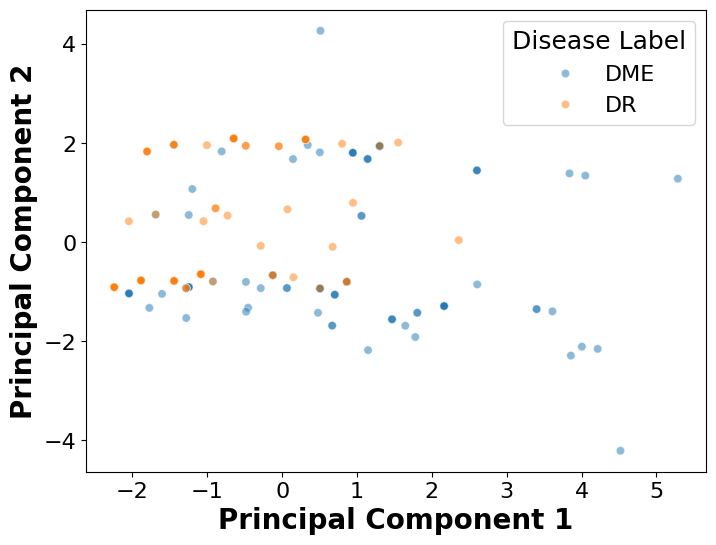

Silhouette Score: 0.17132524692075168
Davies-Bouldin Index (PCA): 1.3402104003800732
Calinski-Harabasz Index (PCA): 64.3819445110099


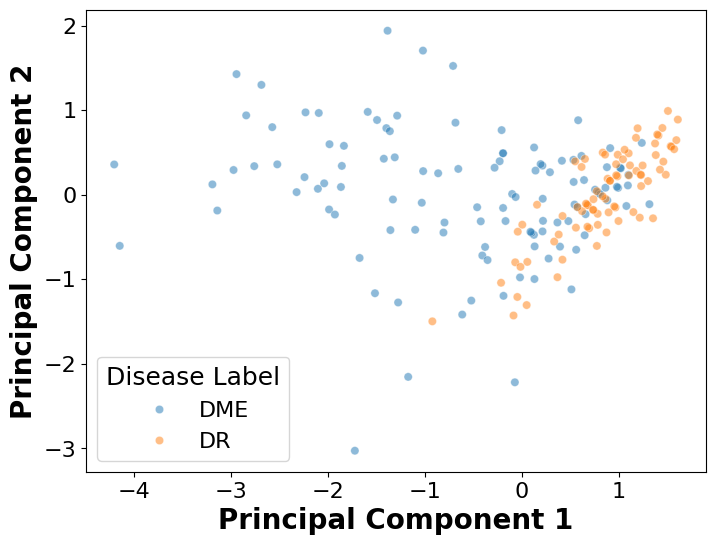

Silhouette Score: 0.17330794622259693
Davies-Bouldin Index (PCA): 1.6274611059513593
Calinski-Harabasz Index (PCA): 52.80935082025996


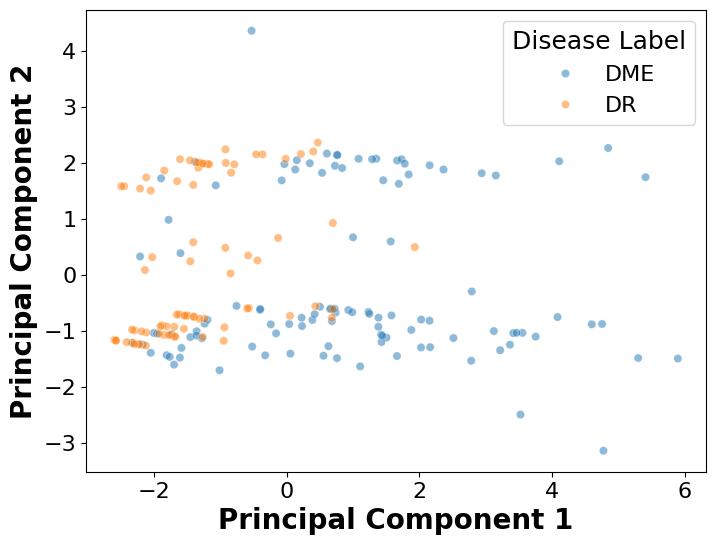

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

X = all_data

for X in [biomarkers, clinical_labels, all_data]:
  # Scale the data
  x = StandardScaler().fit_transform(X)

  # Apply PCA with 2 components
  pca = PCA(n_components=2)
  principalComponents = pca.fit_transform(x)
  principalDf = pd.DataFrame(data = principalComponents
              , columns = ['principal component 1', 'principal component 2'])

  # Calculate Silhouette Score
  silhoutte_avg = silhouette_score(principalComponents, data['Disease Label'])
  print(f"Silhouette Score: {silhoutte_avg}")

  # Calculate Davies-Bouldin index
  davies_bouldin = davies_bouldin_score(principalComponents, data['Disease Label'])
  print(f"Davies-Bouldin Index (PCA): {davies_bouldin}")

  # Calculate Calinski-Harabasz index
  calinski_harabasz = calinski_harabasz_score(principalComponents, data['Disease Label'])
  print(f"Calinski-Harabasz Index (PCA): {calinski_harabasz}")

  # Add 'Disease Label' column to principal components
  principalDf['Disease Label'] = data['Disease Label']

  # Create a scatter plot
  plt.figure(figsize=(8,6))
  sns.scatterplot(x='principal component 1', y='principal component 2', hue='Disease Label', data=principalDf, alpha=0.5)
  # plt.title('PCA of data with diseases seperated')
  # plt.show()

  # Increase font sizes and weights
  plt.xlabel("Principal Component 1", fontsize=20, fontweight='bold')
  plt.ylabel("Principal Component 2", fontsize=20, fontweight='bold')
  # plt.title("2D PCA", fontsize=16, fontweight='bold')
  plt.legend(title="Disease Label", title_fontsize=18, fontsize=16)
  plt.xticks(fontsize=16)
  plt.yticks(fontsize=16)
  plt.show()

3 component PCA:

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = all_data

for X in [biomarkers, all_data]:
  # Scale the data
  x = StandardScaler().fit_transform(X)

  # Apply PCA with 2 components
  principalComponents = pca.fit_transform(x)
  principalDf = pd.DataFrame(data = principalComponents
              , columns = ['principal component 1', 'principal component 2', 'principal component 3'])

  # Calculate Silhouette Score
  silhoutte_avg = silhouette_score(principalComponents, data['Disease Label'])
  print(f"Silhouette Score: {silhoutte_avg}")

  # Calculate Davies-Bouldin index
  davies_bouldin = davies_bouldin_score(principalComponents, data['Disease Label'])
  print(f"Davies-Bouldin Index (PCA): {davies_bouldin}")

  # Calculate Calinski-Harabasz index
  calinski_harabasz = calinski_harabasz_score(principalComponents, data['Disease Label'])
  print(f"Calinski-Harabasz Index (PCA): {calinski_harabasz}")

  # Add 'Disease Label' column to principal components
  principalDf['Disease Label'] = data['Disease Label']

  import plotly.express as px
  fig = px.scatter_3d(principalDf, x='principal component 1', y='principal component 2', z='principal component 3', color='Disease Label')
  fig.update_traces(marker=dict(size=2))
  fig.show()



Silhouette Score: 0.1287005593002781
Davies-Bouldin Index (PCA): 2.143162523300141
Calinski-Harabasz Index (PCA): 29.613256086713474


Silhouette Score: 0.15555372895821598
Davies-Bouldin Index (PCA): 1.7697494621879986
Calinski-Harabasz Index (PCA): 42.510707619530685


**Kernel PCA:**

Silhouette Score: 0.22085465027205547
Davies-Bouldin Index (PCA): 1.7633060461221388
Calinski-Harabasz Index (PCA): 39.86082677798848


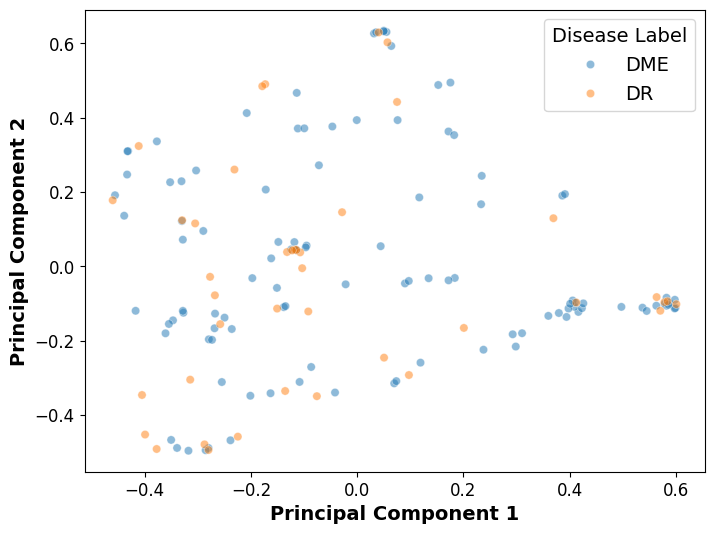

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import train_test_split

X = all_data
y = data['Disease Label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply Kernel PCA
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1)  # Adjust kernel and parameters
# kpca = KernelPCA(n_components=2, kernel='sigmoid', gamma=1)
X_train_kpca = kpca.fit_transform(X_train_scaled)
X_test_kpca = kpca.transform(X_test_scaled)

# Extract principal components
principalDf = pd.DataFrame(data = X_train_kpca,
                           columns = ['principal component 1', 'principal component 2'])

# Calculate Silhouette Score
silhoutte_avg = silhouette_score(X_train_kpca, y_train)
print(f"Silhouette Score: {silhoutte_avg}")

# Calculate Davies-Bouldin index
davies_bouldin = davies_bouldin_score(X_train_kpca, y_train)
print(f"Davies-Bouldin Index (PCA): {davies_bouldin}")

# Calculate Calinski-Harabasz index
calinski_harabasz = calinski_harabasz_score(X_train_kpca, y_train)
print(f"Calinski-Harabasz Index (PCA): {calinski_harabasz}")

# Add 'Disease Label' column to principal components
principalDf['Disease Label'] = data['Disease Label']

# Create a scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='principal component 1', y='principal component 2', hue='Disease Label', data=principalDf, alpha=0.5)
# plt.title('PCA of data with diseases seperated')
# plt.show()

# Increase font sizes and weights
plt.xlabel("Principal Component 1", fontsize=14, fontweight='bold')
plt.ylabel("Principal Component 2", fontsize=14, fontweight='bold')
# plt.title("2D Kernel PCA", fontsize=16, fontweight='bold')
plt.legend(title="Disease Label", title_fontsize=14, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import train_test_split

# Select data
X = all_data
y = data['Disease Label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply Kernel PCA
kpca = KernelPCA(n_components=3, kernel='rbf', gamma=0.1)  # Adjust kernel and parameters
# kpca = KernelPCA(n_components=3, kernel='sigmoid', gamma=10)
X_train_kpca = kpca.fit_transform(X_train_scaled)
X_test_kpca = kpca.transform(X_test_scaled)

# Extract principal components
principalDf = pd.DataFrame(data = X_train_kpca,
                           columns = ['principal component 1', 'principal component 2', 'principal component 3'])

# Calculate Silhouette Score
silhoutte_avg = silhouette_score(X_train_kpca, y_train)
print(f"Silhouette Score: {silhoutte_avg}")

# Calculate Davies-Bouldin index
davies_bouldin = davies_bouldin_score(X_train_kpca, y_train)
print(f"Davies-Bouldin Index (PCA): {davies_bouldin}")

# Calculate Calinski-Harabasz index
calinski_harabasz = calinski_harabasz_score(X_train_kpca, y_train)
print(f"Calinski-Harabasz Index (PCA): {calinski_harabasz}")

# Add 'Disease Label' column to principal components
principalDf['Disease Label'] = data['Disease Label']

# Create a scatter plot
import plotly.express as px
fig = px.scatter_3d(principalDf, x='principal component 1', y='principal component 2', z='principal component 3', color='Disease Label')
fig.update_traces(marker=dict(size=2))
fig.show()

Silhouette Score: 0.17907894648414047
Davies-Bouldin Index (PCA): 2.0877147661310373
Calinski-Harabasz Index (PCA): 30.15249565801845


**t-Distributed Stochastic Neighbour Embedding:**

Best for high-dimensional, nonlinear data where you want to capture local structure and group clusters. \\
Computationally intensive on large datasets, and the results can vary depending on the perplexity and learning rate.

Silhouette Score: 0.04212290048599243
Davies-Bouldin Index (PCA): 5.896079411611312
Calinski-Harabasz Index (PCA): 4.3857891459607785


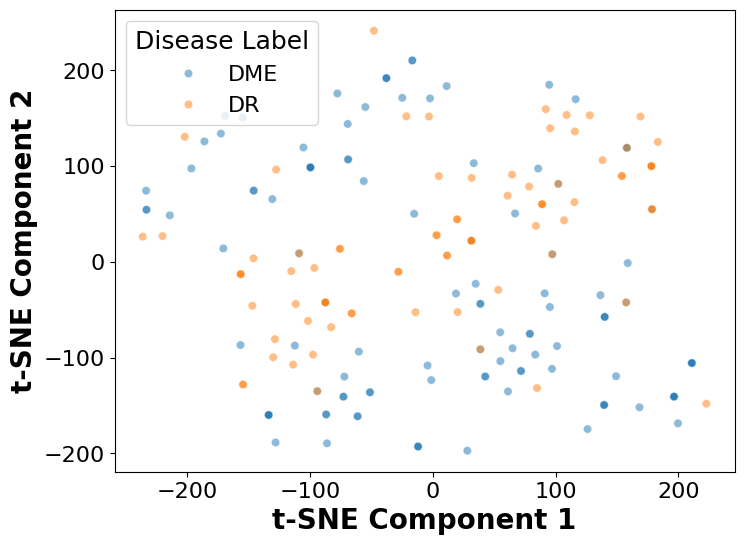

Silhouette Score: 0.2593343257904053
Davies-Bouldin Index (PCA): 1.1775956775114482
Calinski-Harabasz Index (PCA): 97.60634438052926


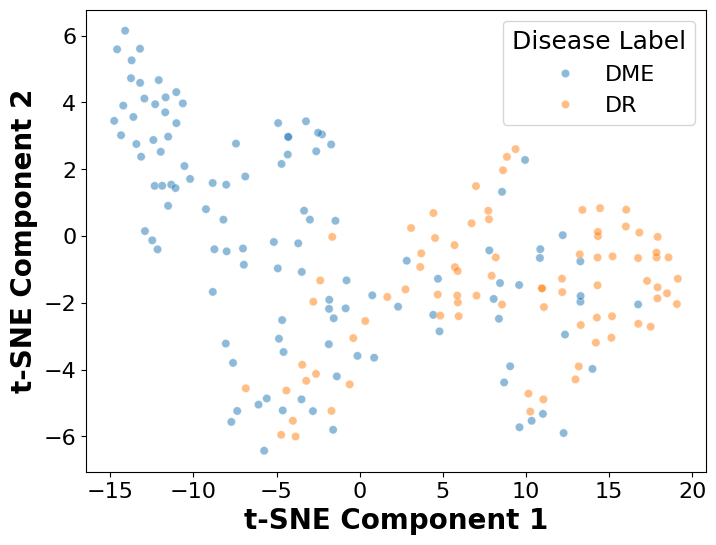

Silhouette Score: 0.18660719692707062
Davies-Bouldin Index (PCA): 1.90265014909907
Calinski-Harabasz Index (PCA): 40.87322474743692


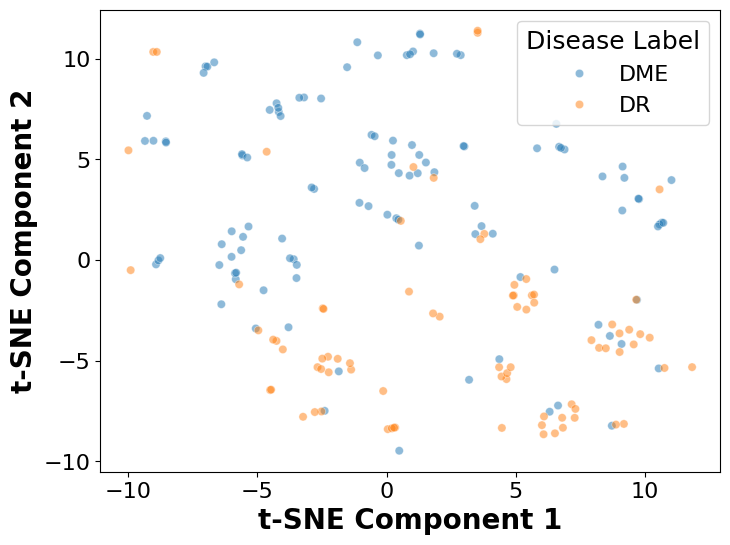

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


X = all_data

for X in [biomarkers, clinical_labels, all_data]:
  # Scale the data
  x = StandardScaler().fit_transform(X)

  # Apply t-SNE with 2 components
  tsne = TSNE(n_components=2, random_state=42)
  tsne_results = tsne.fit_transform(x)

  principalComponents = tsne.fit_transform(x)
  principalDf = pd.DataFrame(data = principalComponents
              , columns = ['principal component 1', 'principal component 2'])

  # Calculate Silhouette Score
  silhoutte_avg = silhouette_score(principalComponents, data['Disease Label'])
  print(f"Silhouette Score: {silhoutte_avg}")

  # Calculate Davies-Bouldin index
  davies_bouldin = davies_bouldin_score(principalComponents, data['Disease Label'])
  print(f"Davies-Bouldin Index (PCA): {davies_bouldin}")

  # Calculate Calinski-Harabasz index
  calinski_harabasz = calinski_harabasz_score(principalComponents, data['Disease Label'])
  print(f"Calinski-Harabasz Index (PCA): {calinski_harabasz}")

  # Add 'Disease Label' column to principal components
  principalDf['Disease Label'] = data['Disease Label']

  # Create a scatter plot
  plt.figure(figsize=(8,6))
  sns.scatterplot(x='principal component 1', y='principal component 2', hue='Disease Label', data=principalDf, alpha=0.5)
  # plt.title('tsne of data with diseases seperated')
  # plt.show()

  # Increase font sizes and weights
  plt.xlabel("t-SNE Component 1", fontsize=20, fontweight='bold')
  plt.ylabel("t-SNE Component 2", fontsize=20, fontweight='bold')
  # plt.title("2D t-SNE", fontsize=16, fontweight='bold')
  plt.legend(title="Disease Label", title_fontsize=18, fontsize=16)
  plt.xticks(fontsize=16)
  plt.yticks(fontsize=16)
  plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


X = all_data

for X in [biomarkers, all_data]:
  # Scale the data
  x = StandardScaler().fit_transform(X)

  # Apply t-SNE with 2 components
  tsne = TSNE(n_components=3, random_state=42)
  tsne_results = tsne.fit_transform(x)
  principalComponents = tsne.fit_transform(x)

  # Calculate Silhouette Score
  silhoutte_avg = silhouette_score(principalComponents, data['Disease Label'])
  print(f"Silhouette Score: {silhoutte_avg}")

  # Calculate Davies-Bouldin index
  davies_bouldin = davies_bouldin_score(principalComponents, data['Disease Label'])
  print(f"Davies-Bouldin Index (PCA): {davies_bouldin}")

  # Calculate Calinski-Harabasz index
  calinski_harabasz = calinski_harabasz_score(principalComponents, data['Disease Label'])
  print(f"Calinski-Harabasz Index (PCA): {calinski_harabasz}")

  # t-SNE results
  tsne_df = pd.DataFrame(data=tsne_results, columns=['t-SNE Component 1', 't-SNE Component 2', 't-SNE Component 3'])

  # # Visualize the data distribution (2D)
  # plt.figure(figsize=(8, 6))
  # plt.scatter(tsne_df['t-SNE Component 1'], tsne_df['t-SNE Component 2'], alpha=0.5)
  # plt.xlabel('t-SNE Component 1')
  # plt.ylabel('t-SNE Component 2')
  # plt.title('Data Distribution using t-SNE')
  # plt.show()


  tsne_df['Disease Label'] = data['Disease Label']

  import plotly.express as px
  fig = px.scatter_3d(tsne_df, x='t-SNE Component 1', y='t-SNE Component 2', z='t-SNE Component 3', color='Disease Label')
  fig.update_traces(marker=dict(size=2))
  fig.show()


Silhouette Score: 0.12616705894470215
Davies-Bouldin Index (PCA): 2.3775836266219263
Calinski-Harabasz Index (PCA): 29.382340695429242


Silhouette Score: 0.10230743885040283
Davies-Bouldin Index (PCA): 2.837697066504772
Calinski-Harabasz Index (PCA): 20.256036975614155


Silhouette Score: 0.07427438348531723
Davies-Bouldin Index (PCA): 3.553516088326471
Calinski-Harabasz Index (PCA): 11.114943366347042


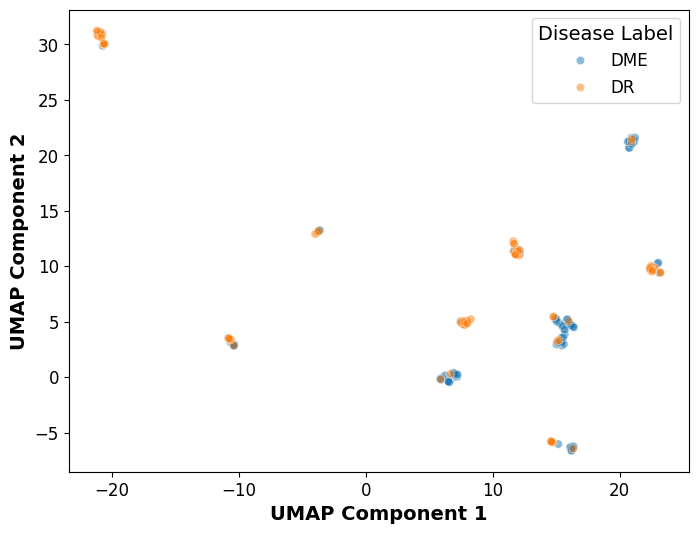

Silhouette Score: 0.239091694355011
Davies-Bouldin Index (PCA): 1.4242234898671158
Calinski-Harabasz Index (PCA): 74.29262961001507


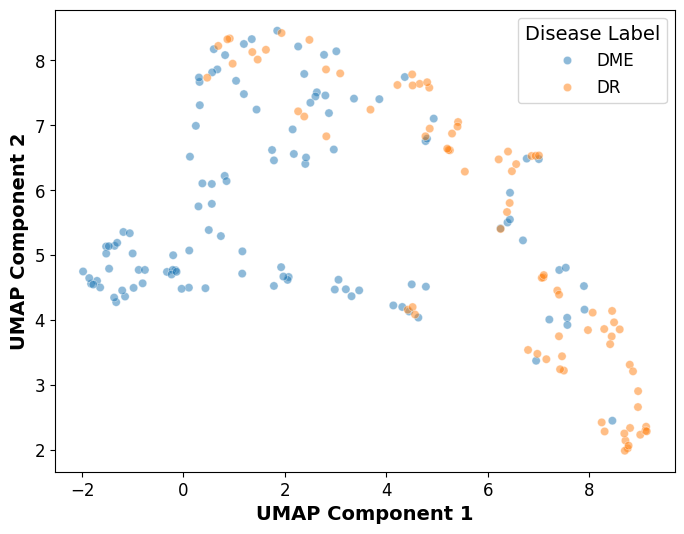

Silhouette Score: 0.17102931439876556
Davies-Bouldin Index (PCA): 1.918819356813444
Calinski-Harabasz Index (PCA): 34.850880811046345


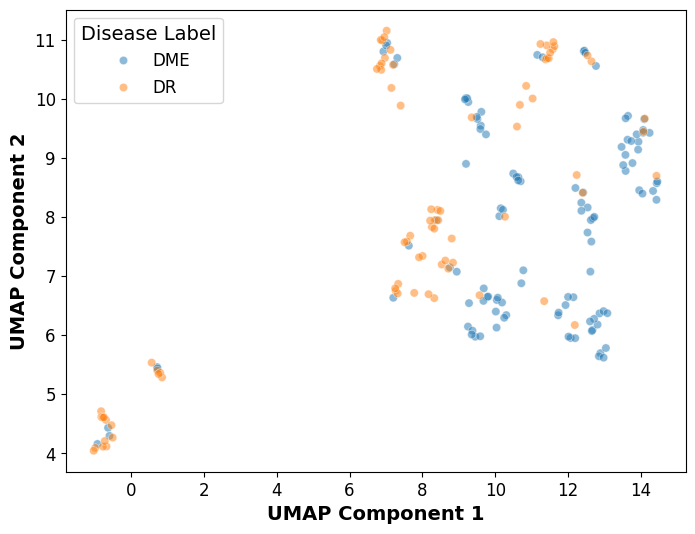

In [ ]:
!pip install -q umap-learn==0.5.3
import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

X = all_data

for X in [biomarkers, clinical_labels, all_data]:
  # Scale the data
  x = StandardScaler().fit_transform(X)

  # Applying UMAP with 2 components
  reducer = umap.UMAP(n_components=2, random_state=3)
  embedding = reducer.fit_transform(x)

  # Calculate Silhouette Score
  silhoutte_avg = silhouette_score(embedding, data['Disease Label'])
  print(f"Silhouette Score: {silhoutte_avg}")

  # Calculate Davies-Bouldin index
  davies_bouldin = davies_bouldin_score(embedding, data['Disease Label'])
  print(f"Davies-Bouldin Index (PCA): {davies_bouldin}")

  # Calculate Calinski-Harabasz index
  calinski_harabasz = calinski_harabasz_score(embedding, data['Disease Label'])
  print(f"Calinski-Harabasz Index (PCA): {calinski_harabasz}")

  # Create a DataFrame for the UMAP results
  umap_df = pd.DataFrame(data=embedding, columns=['UMAP Component 1', 'UMAP Component 2'])

  umap_df['Disease Label'] = data['Disease Label']

  # Create a scatter plot
  plt.figure(figsize=(8,6))
  sns.scatterplot(x='UMAP Component 1', y='UMAP Component 2', hue='Disease Label', data=umap_df, alpha=0.5)
  # plt.title('UMAP of data with diseases seperated')
  # plt.show()

  # Increase font sizes and weights
  plt.xlabel("UMAP Component 1", fontsize=14, fontweight='bold')
  plt.ylabel("UMAP Component 2", fontsize=14, fontweight='bold')
  # plt.title("2D UMAP", fontsize=16, fontweight='bold')
  plt.legend(title="Disease Label", title_fontsize=14, fontsize=12)
  plt.xticks(fontsize=12)
  plt.yticks(fontsize=12)
  plt.show()



3 Component UMAPs:

In [ ]:

!pip install -q umap-learn==0.5.3
import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

X = data.select_dtypes(include=np.number)

# Scale the data
x = StandardScaler().fit_transform(X)

# Applying UMAP with 2 components
reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=34)
embedding = reducer.fit_transform(x)

# Calculate Silhouette Score
silhoutte_avg = silhouette_score(embedding, data['Disease Label'])
print(f"Silhouette Score: {silhoutte_avg}")

# Calculate Davies-Bouldin index
davies_bouldin = davies_bouldin_score(embedding, data['Disease Label'])
print(f"Davies-Bouldin Index (PCA): {davies_bouldin}")

# Calculate Calinski-Harabasz index
calinski_harabasz = calinski_harabasz_score(embedding, data['Disease Label'])
print(f"Calinski-Harabasz Index (PCA): {calinski_harabasz}")

umap_df = pd.DataFrame(data=embedding, columns=['UMAP Component 1', 'UMAP Component 2', 'UMAP Component 3'])

umap_df['Disease Label'] = data['Disease Label']

import plotly.express as px
fig = px.scatter_3d(umap_df, x='UMAP Component 1', y='UMAP Component 2', z='UMAP Component 3', color='Disease Label')
fig.update_traces(marker=dict(size=2))
fig.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 2.4 MB/s eta 0:00:00
Silhouette Score: 0.3014470040798187
Davies-Bouldin Index (PCA): 1.2885297464889922
Calinski-Harabasz Index (PCA): 92.5001013058585


Iterative code to try to identify the random state for optimal clustering and disease seperation of data points:

In [ ]:
!pip install -q umap-learn==0.5.3
import umap
from sklearn.metrics import silhouette_score

best_random_state = None
best_silhouette = -1

for random_state in range(50):
    reducer = umap.UMAP(n_components=3, random_state=random_state)
    embedding = reducer.fit_transform(x)

    silhouette_avg = silhouette_score(embedding, umap_df['Disease Label'])

    if silhouette_avg > best_silhouette:
        best_silhouette = silhouette_avg
        best_random_state = random_state

print(f"Best random_state: {best_random_state}, Silhouette Score: {best_silhouette}")


Best random_state: 34, Silhouette Score: 0.3014470040798187


# **Task 1.2**

In [ ]:
from google.colab import drive

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import display

# Import dataset
data = pd.read_csv('/content/drive/MyDrive/AI Coursework/Biomarker_Clinical_Data_Images_2.csv (17KB)')
display(data)

# Extract binary Biomarkers
biomarkers = data.iloc[:, list(range(1, 17))]

# Extract numerical Clinical Labels
clinical_labels = data.iloc[:, [18,19]]

# Extract Combination of Biomarkers and Clinical Labels
all_data = data.iloc[:, list(range(1, 17)) + [18, 19]]

,Path,Biomarker 1,Biomarker 2,Biomarker 3,Biomarker 4,Biomarker 5,Biomarker 6,Biomarker 7,Biomarker 8,Biomarker 9,...,Biomarker 11,Biomarker 12,Biomarker 13,Biomarker 14,Biomarker 15,Biomarker 16,Eye_ID,BCVA,CST,Disease Label
0,/TREX DME/GILA/0201GOD/V1/OD/TREXJ_000024.tif,0,0,0,0,1,0,1,0,0,...,1,1,1,0,0,0,1,61,575,DME
1,/TREX DME/GILA/0201GOD/V22/OD/TREX_DME_000024.tif,0,1,0,0,1,0,1,0,0,...,0,1,0,0,0,0,1,71,241,DME
2,/TREX DME/GILA/0203GOS/V1/OS/TREXS_000024.tif,0,0,0,0,1,0,1,0,0,...,1,1,0,0,0,0,2,80,392,DME
3,/TREX DME/GILA/0203GOS/V15/OS/TREX_DME_000024.tif,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,2,85,270,DME
4,/TREX DME/GILA/0204GOS/V1/OS/TREXD_000024.tif,0,0,0,0,1,1,0,0,0,...,1,1,0,0,0,0,3,62,539,DME
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,/Prime_FULL/02-044/W36/OS/24.tif,0,0,0,0,1,0,1,0,1,...,0,0,0,0,0,0,94,86,199,DR
188,/Prime_FULL/02-045/W0/OS/24.tif,0,0,0,0,1,0,0,0,0,...,1,1,1,0,0,0,95,74,302,DR
189,/Prime_FULL/02-045/W104/OS/24.tif,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,95,68,222,DR
190,/Prime_FULL/02-046/W0/OD/24.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,96,89,283,DR


**Applying Support Vector Machine (SVM)**

Accuracy: 0.925
Precision: 0.932258064516129
Recall: 0.925
F1-Score: 0.921549636803874
Average ROC AUC (OvR): 0.875


PermutationExplainer explainer: 41it [00:28,  1.10s/it]


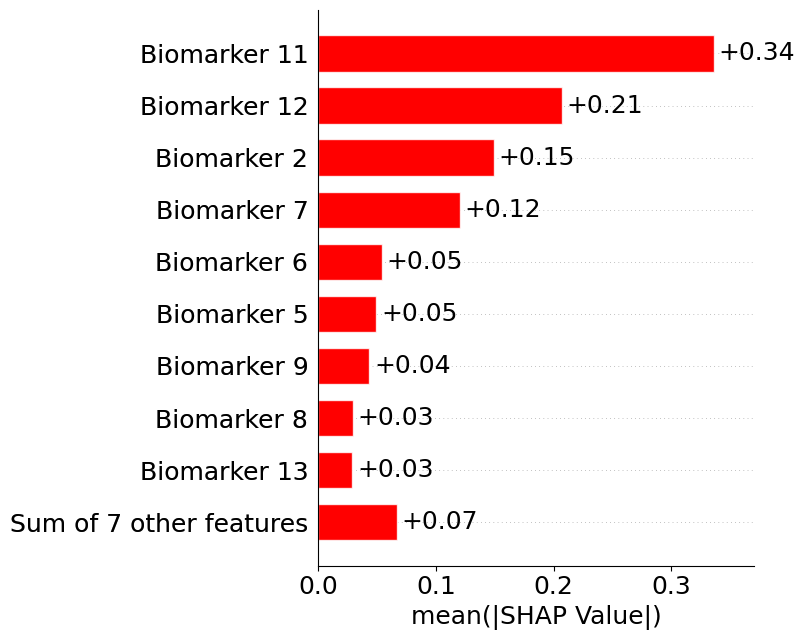

Accuracy: 0.725
Precision: 0.7912280701754385
Recall: 0.725
F1-Score: 0.7364055299539171
Average ROC AUC (OvR): 0.7559523809523812


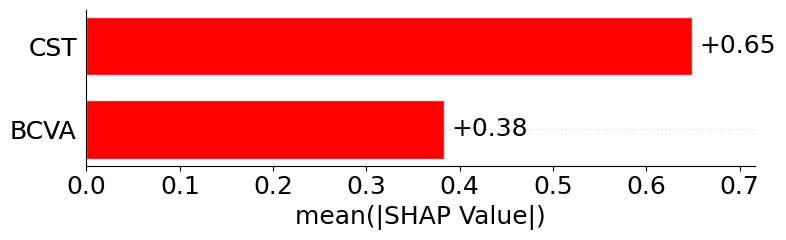

Accuracy: 0.85
Precision: 0.8764705882352942
Recall: 0.85
F1-Score: 0.832258064516129
Average ROC AUC (OvR): 0.75


PermutationExplainer explainer: 41it [00:29,  1.42s/it]


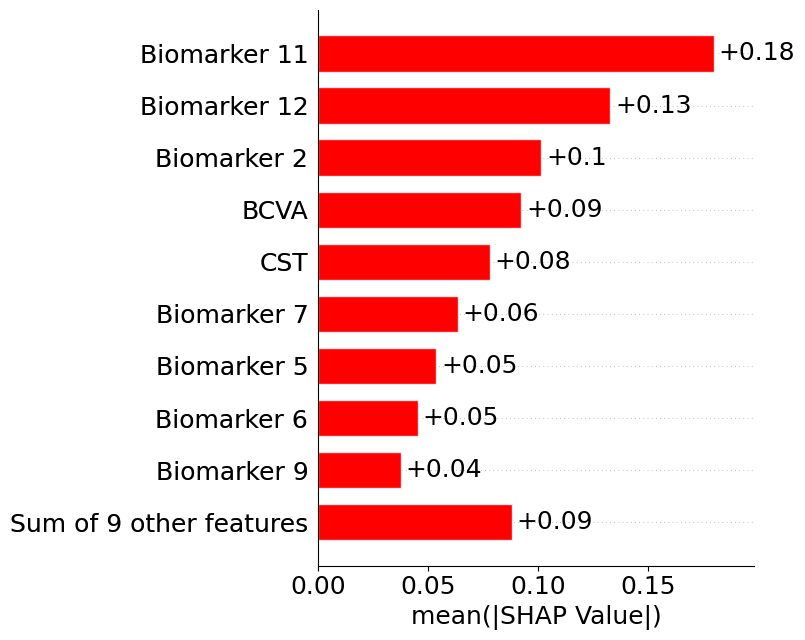

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from sklearn.svm import SVC

eye_ids = data['Eye_ID']

# Create a GroupShuffleSplit instance
splitter = GroupShuffleSplit(test_size=0.2, random_state=42)

for X in [biomarkers, clinical_labels, all_data]:

  x = StandardScaler().fit_transform(X)  # Scale data
  x = pd.DataFrame(x, columns=X.columns) # Convert back to dataframe

  # Split data into training and testing sets
  for train_indices, test_indices in splitter.split(x, groups=eye_ids):
      x_train = x.iloc[train_indices]
      x_test = x.iloc[test_indices]
      y_train = data.iloc[train_indices]['Disease Label']
      y_test = data.iloc[test_indices]['Disease Label']

  from sklearn.preprocessing import LabelEncoder
  from tensorflow.keras.utils import to_categorical

  y_train_encoded = LabelEncoder().fit_transform(y_train)
  y_test_encoded = LabelEncoder().fit_transform(y_test)

  # Set up Support Vector model
  # model = SVC(kernel='linear', probability = True)
  # model = SVC(kernel='poly', degree=2)
  model = SVC(kernel='rbf', gamma=1, C=1, probability=True)
  model.fit(x_train, y_train)


  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

  # Encode predicted and test labels to calculate metrics
  y_pred = model.predict(x_test)
  label_encoder = LabelEncoder()
  y_pred = label_encoder.fit_transform(y_pred)
  y_test = label_encoder.fit_transform(y_test)

  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average='weighted')
  recall = recall_score(y_test, y_pred, average='weighted')
  f1 = f1_score(y_test, y_pred, average='weighted')
  roc_auc = roc_auc_score(y_test, y_pred, multi_class='ovr')

  print(f"Accuracy: {accuracy}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1-Score: {f1}")
  print(f"Average ROC AUC (OvR): {roc_auc}")

  # # !pip install shap==0.41.0
  import shap
  from shap import KernelExplainer

  # Create a TreeExplainer object for the SVM model
  # explainer = shap.Explainer(model.predict, x_train)
  # explainer = shap.Explainer(model.predict_proba, x_train)
  explainer = shap.Explainer(model.decision_function, x_train)

  # Calculate SHAP values for the test set
  shap_values = explainer(x_test)

  bar = shap.plots.bar(shap_values, show=False)

  # Access the matplotlib axes object
  ax = plt.gca()

  for patch in ax.patches:
    patch.set_facecolor('red')

  # Change the color of the numbers next to the bars
  for text in ax.texts:
      text.set_color('black')  # Example: Set numbers to red
      text.set_fontsize(18)

  # Increase font size of labels and ticks
  plt.tick_params(axis='both', which='major', labelsize=18)  # Adjust labelsize as needed
  plt.xlabel("mean(|SHAP Value|)", fontsize=18)  # Adjust fontsize as needed

  plt.tight_layout()  # Adjust layout to prevent overlapping labels

  plt.show() # Display the plot


**Applying a Neural Network**

rmsprop optimiser (Root Mean Squared Propagation)

Adam optimiser

model: epochs (number of iterations), batch_size (subset size to be processed)

obtura opimiser


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,106 (4.32 KB)

 Trainable params: 1,106 (4.32 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.4440 - loss: 1.2226 - val_accuracy: 0.5484 - val_loss: 1.0712
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5192 - loss: 1.1106 - val_accuracy: 0.5484 - val_loss: 1.0739
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6968 - loss: 1.0016 - val_accuracy: 0.5161 - val_loss: 1.0919
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5480 - loss: 0.9987 - val_accuracy: 0.5161 - val_loss: 1.1005
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7300 - loss: 0.8808 - val_accuracy: 0.5484 - val_loss: 1.1031
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7498 - loss: 0.9167 - val_accuracy: 0.5484 - val_loss: 1.1216
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7655 - loss: 0.8086 - val_accuracy: 0.5484 - val_loss: 1.1228
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8815 - loss: 0.7288 - val_accuracy:

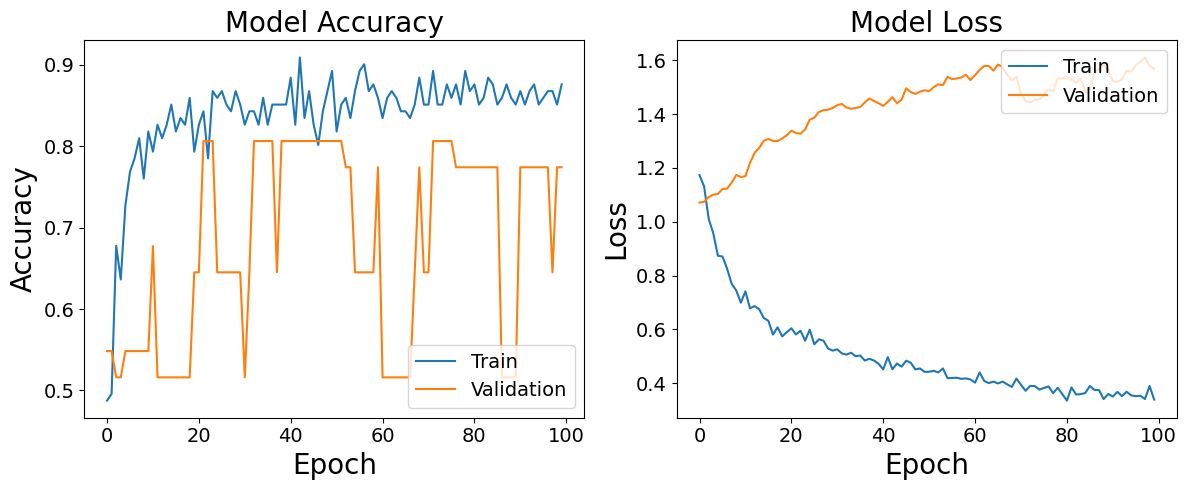

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step
Accuracy: 0.875
Precision: 0.878917378917379
Recall: 0.875
F1-Score: 0.8763636363636363
Average ROC AUC (OvR): 0.863095238095238
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step  
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step  
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step  
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step  
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━

PermutationExplainer explainer:   2%|▎         | 1/40 [00:00<?, ?it/s]

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step  
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step  
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step  
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step  
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step  
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step  
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 


PermutationExplainer explainer:   8%|▊         | 3/40 [00:24<03:45,  6.10s/it]

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step  
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step  
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


...

PermutationExplainer explainer:  98%|█████████▊| 39/40 [09:01<00:12, 12.12s/it]

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step  
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step  
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step  
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step 


PermutationExplainer explainer: 100%|██████████| 40/40 [09:16<00:00, 12.98s/it]

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step  
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step  
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step  
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step  
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step  
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step  
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step  
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step  


PermutationExplainer explainer: 41it [09:32, 14.32s/it]


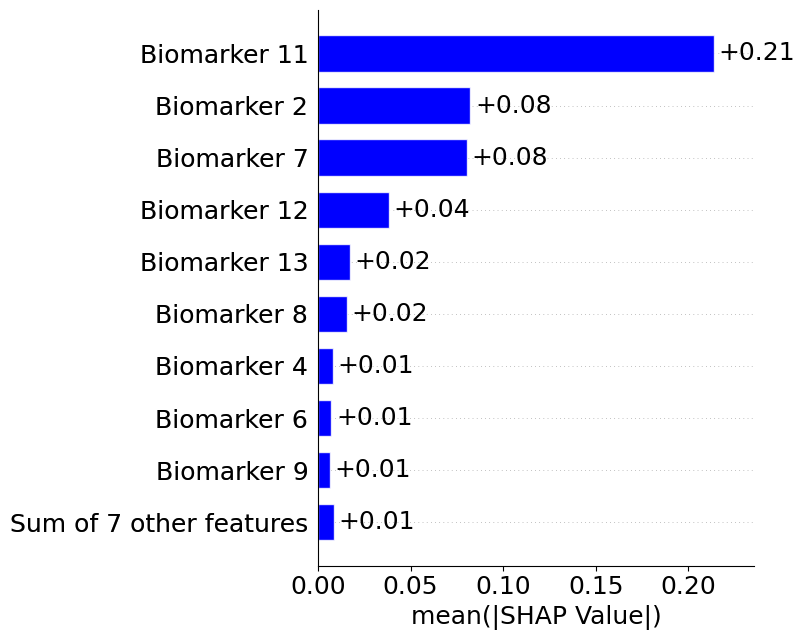

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 32)                  │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 658 (2.57 KB)

 Trainable params: 658 (2.57 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5796 - loss: 0.8792 - val_accuracy: 0.8065 - val_loss: 0.9518
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6793 - loss: 0.8335 - val_accuracy: 0.8065 - val_loss: 0.8802
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7227 - loss: 0.7424 - val_accuracy: 0.8065 - val_loss: 0.8467
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6701 - loss: 0.7494 - val_accuracy: 0.8065 - val_loss: 0.8347
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7299 - loss: 0.7511 - val_accuracy: 0.8065 - val_loss: 0.8154
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6644 - loss: 0.7340 - val_accuracy: 0.8065 - val_loss: 0.8378
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7927 - loss: 0.6856 - val_accuracy: 0.8065 - val_loss: 0.8453
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6924 - loss: 0.7600 - val_accuracy: 0.

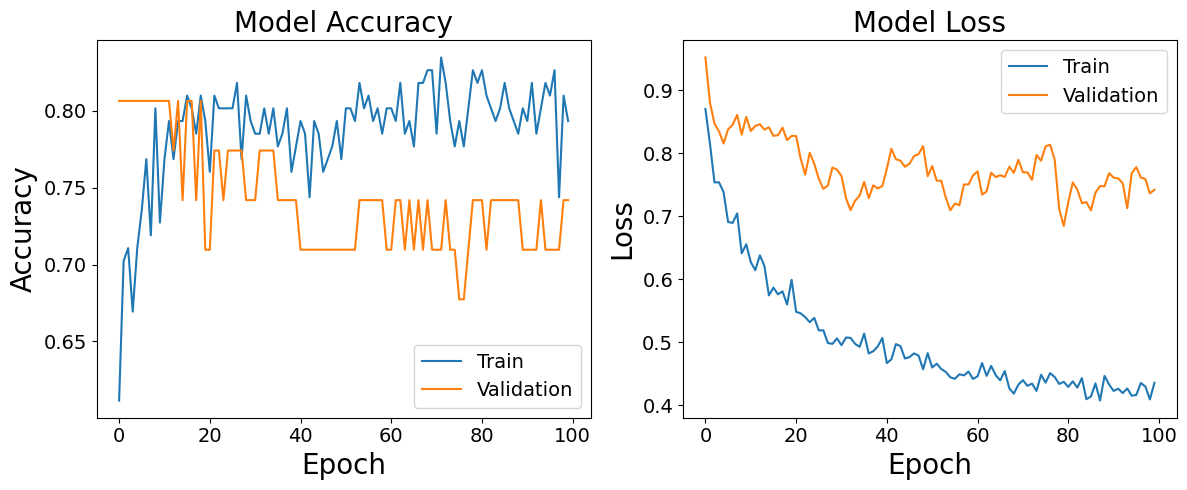

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
Accuracy: 0.75
Precision: 0.7637362637362638
Recall: 0.75
F1-Score: 0.7549857549857549
Average ROC AUC (OvR): 0.7261904761904762
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━

ExactExplainer explainer:  30%|███       | 12/40 [00:00<?, ?it/s]

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  35%|███▌      | 14/40 [00:11<00:03,  6.74it/s]

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


...

ExactExplainer explainer:  98%|█████████▊| 39/40 [00:33<00:00,  1.45it/s]

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer: 100%|██████████| 40/40 [00:33<00:00,  1.76it/s]

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step 


ExactExplainer explainer: 41it [00:36,  1.26s/it]


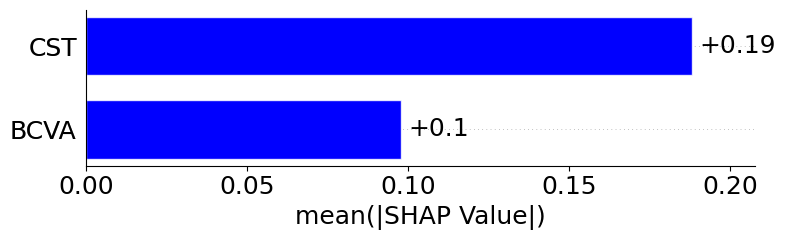

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 32)                  │             608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,170 (4.57 KB)

 Trainable params: 1,170 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.5941 - loss: 1.1576 - val_accuracy: 0.4839 - val_loss: 1.2032
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7504 - loss: 0.9035 - val_accuracy: 0.5806 - val_loss: 1.1341
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7847 - loss: 0.8841 - val_accuracy: 0.6129 - val_loss: 1.0965
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7215 - loss: 0.9317 - val_accuracy: 0.7097 - val_loss: 1.0452
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7401 - loss: 0.9281 - val_accuracy: 0.7419 - val_loss: 1.0398
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8231 - loss: 0.7765 - val_accuracy: 0.7419 - val_loss: 1.0213
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7937 - loss: 0.7969 - val_accuracy: 0.7419 - val_loss: 1.0164
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7941 - loss: 0.7531 - val_accuracy: 0.

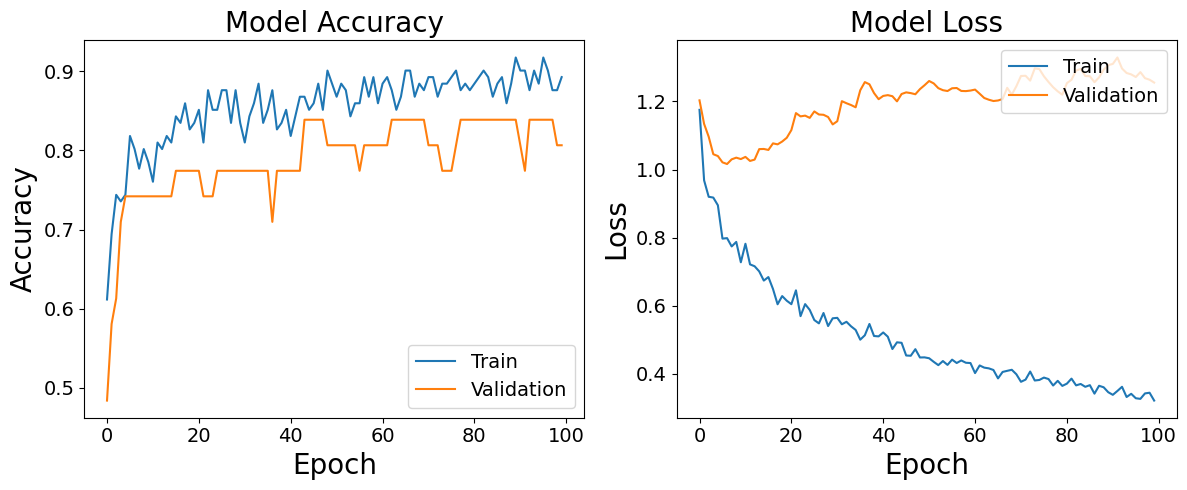

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Accuracy: 0.85
Precision: 0.8604395604395604
Recall: 0.85
F1-Score: 0.852991452991453
Average ROC AUC (OvR): 0.8452380952380952
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


PermutationExplainer explainer:   2%|▎         | 1/40 [00:00<?, ?it/s]

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


PermutationExplainer explainer:   8%|▊         | 3/40 [00:26<04:01,  6.54s/it]

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


...

PermutationExplainer explainer:  98%|█████████▊| 39/40 [08:59<00:13, 13.50s/it]

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


PermutationExplainer explainer: 100%|██████████| 40/40 [09:15<00:00, 14.44s/it]

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


PermutationExplainer explainer: 41it [09:29, 14.23s/it]


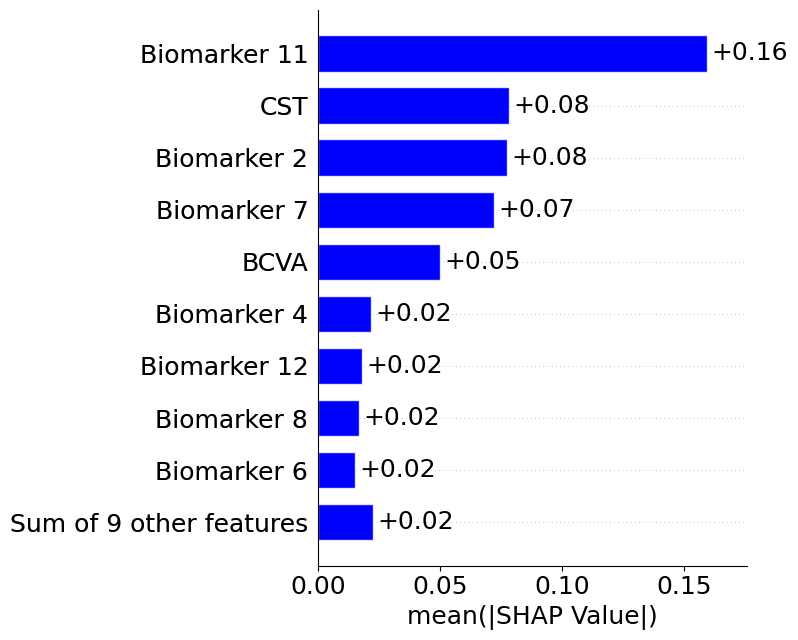

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.optimizers import Adam

eye_ids = data['Eye_ID']

# Create a GroupShuffleSplit instance
splitter = GroupShuffleSplit(test_size=0.2, random_state=42)

for X in [biomarkers, clinical_labels, all_data]:

  x = StandardScaler().fit_transform(X)  # Scale data
  x = pd.DataFrame(x, columns=X.columns) # Convert back to dataframe

  # Convert disease labels into binary to be compatible with model
  y = data['Disease Label']
  y = np.where(y== 'DME', 1, 0)
  y = pd.DataFrame(y)

  # Split data into training and testing sets
  for train_indices, test_indices in splitter.split(x, groups=eye_ids):
      x_train = x.iloc[train_indices]
      x_test = x.iloc[test_indices]
      y_train = y.iloc[train_indices]
      y_test = y.iloc[test_indices]

  # x_train = x_train.to_numpy()
  # x_test = x_test.to_numpy()

  from sklearn.preprocessing import LabelEncoder
  from tensorflow.keras.utils import to_categorical

  y_train = LabelEncoder().fit_transform(y_train)
  y_train = to_categorical(y_train)
  y_test = LabelEncoder().fit_transform(y_test)
  y_test = to_categorical(y_test)

  # y_train = np.where(y_train== 'DME', 1, 0) # DME=1, DR=0
  # y_train = pd.DataFrame(y_train)
  # y_test = np.where(y_test== 'DME', 1, 0) # DME=1, DR=0
  # y_test = pd.DataFrame(y_test)

  # Set up neural network
  from keras.regularizers import l1, l2
  num_inputs = x_train.shape[1]

  model = Sequential()
  # model.add(Dense(16, input_shape = (num_inputs,), kernel_regularizer=l2(0.01)))
  # model.add(Dense(32, activation = 'relu', kernel_regularizer=l2(0.01)))
  # model.add(Dense(16, activation = 'relu', kernel_regularizer=l2(0.01)))
  # model.add(Dense(2, activation = 'softmax'))

  model.add(Dense(32, input_shape = (num_inputs,), kernel_regularizer=l2(0.01)))
  model.add(Dropout(0.3))
  model.add(Dense(16, activation = 'relu', kernel_regularizer=l2(0.01)))
  model.add(Dropout(0.3))
  model.add(Dense(2, activation = 'softmax'))

  # model.add(Dense(128, input_shape = (num_inputs,), kernel_regularizer=l2(0.02)))
  # model.add(Dropout(0.5))
  # model.add(Dense(64, activation = 'relu', kernel_regularizer=l2(0.02)))
  # model.add(Dropout(0.5))
  # model.add(Dense(32, activation = 'relu', kernel_regularizer=l2(0.02)))
  # model.add(Dropout(0.5))
  # model.add(Dense(2, activation = 'softmax'))

  # model.add(Dense(64, activation = 'relu', input_shape=(num_inputs,), kernel_regularizer=l2(0.02)))
  # model.add(Dropout(0.5))
  # model.add(Dense(34, activation = 'relu', kernel_regularizer=l2(0.02)))
  # model.add(Dropout(0.5))
  # model.add(Dense(2, activation = 'softmax'))


  from keras.callbacks import EarlyStopping
  early_stopping_monitor = EarlyStopping(patience=2)

  # model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics =['accuracy'])
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics =['accuracy'])
  print(model.summary())

  # Train the model and capture the training history
  history = model.fit(x_train, y_train, validation_split = 0.2, epochs = 100, batch_size = 8)#, callbacks=[early_stopping_monitor])

  # Plotting the training and validation curves
  plt.figure(figsize=(12, 5))

  # Plot training & validation accuracy values
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('Model Accuracy', fontsize=20)
  plt.xlabel('Epoch', fontsize=20)
  plt.ylabel('Accuracy', fontsize=20)
  plt.legend(['Train', 'Validation'], loc='lower right', fontsize=14)
  plt.tick_params(axis='both', which='major', labelsize=14)

  # Plot training & validation loss values
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Model Loss', fontsize=20)
  plt.xlabel('Epoch', fontsize=20)
  plt.ylabel('Loss', fontsize=20)
  plt.legend(['Train', 'Validation'], loc='upper right', fontsize=14)
  plt.tick_params(axis='both', which='major', labelsize=14)

  # Adjust layout to prevent overlapping
  plt.tight_layout()

  # Show the plot
  plt.show()

  # Generate predicted disease labels
  y_pred = model.predict(x_test)
  # y_pred = [round(float(x)) for x in model.predict(x_test)]
  y_pred = np.argmax(y_pred, axis=1)
  y_test = np.argmax(y_test, axis=1)

  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average='weighted')  # Adjust 'average' as needed
  recall = recall_score(y_test, y_pred, average='weighted')  # Adjust 'average' as needed
  f1 = f1_score(y_test, y_pred, average='weighted')  # Adjust 'average' as needed
  roc_auc = roc_auc_score(y_test, y_pred, multi_class='ovr')  # One-vs-Rest AUC

  print(f"Accuracy: {accuracy}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1-Score: {f1}")
  print(f"Average ROC AUC (OvR): {roc_auc}")

  import shap
  from shap import KernelExplainer

  # Create a TreeExplainer object for the SVM model
  explainer = shap.Explainer(model.predict, x_train)
  # explainer = shap.Explainer(model.predict_proba, x_train)
  # explainer = shap.Explainer(model.decision_function, x_train)

  # Calculate SHAP values for the test set
  shap_values = explainer(x_test)
  shap_values_for_class = shap_values[..., 1]

  bar = shap.plots.bar(shap_values_for_class, show=False)

  # Access the matplotlib axes object
  ax = plt.gca()

  for patch in ax.patches:
    patch.set_facecolor('blue')

  # Change the color of the numbers next to the bars
  for text in ax.texts:
      text.set_color('black')  # Example: Set numbers to red
      text.set_fontsize(18)

  # Increase font size of labels and ticks
  plt.tick_params(axis='both', which='major', labelsize=18)  # Adjust labelsize as needed
  plt.xlabel("mean(|SHAP Value|)", fontsize=18)  # Adjust fontsize as needed

  plt.tight_layout()  # Adjust layout to prevent overlapping labels

  plt.show() # Display the plot



Presenting plots and Comparing models:
Find best bunch of hyperparamters and type of both models, find best combinations of data
Find metrics and measurements to compare performance of models
